define the 7 geographical regions (NEC, IM, NC, NWC, QT, SWC, SCC) 

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import matplotlib.patheffects as pe

class ChinaRegionDefiner:
    def __init__(self):
        """
        使用多边形顶点 (经度, 纬度) 定义中国7大区域。
        这些坐标是对行政边界的几何简化，专门用于网格数据的区域平均。
        """
        # self.regions = {
        #     # 1. 东北 (NEC): 黑吉辽
        #     'NEC': np.array([
        #         [119, 43], [119, 54], [136, 54], [136, 39], [123, 39], [120, 40], [119, 43]
        #     ]),
            
        #     # 2. 内蒙古 (IM): 狭长区域，为了简化，这里定义为一个覆盖主体的多边形
        #     'IM': np.array([
        #         [97, 43],   # 西北角 (阿拉善北部)
        #         [97, 39],   # 西南角 (阿拉善南部)
        #         [105, 37],  # 鄂尔多斯南部
        #         [111, 37],  # 呼和浩特/乌兰察布南部边界 (保持在低纬度以包含突出部，但随后向北收)
        #         [116, 40],  # 锡林郭勒南部 (避开北京/河北南部)
        #         [121, 42],  # 通辽/赤峰方向
        #         [126, 51],  # 东北角 (呼伦贝尔东部)
        #         [121, 54],  # 最北端 (额尔古纳方向)
        #         [115, 47],  # 北部中段 (中蒙边界凸起处，原代码缺失部分)
        #         [108, 43],  # 阴山以北边界
        #         [97, 43]    # 闭合回西北角
        #                   ]),
            
        #     # 3. 西北 (NWC): 新疆、甘肃北部
        #     'NWC': np.array([
        #         [73, 34], [96, 34], [96, 43], [105, 43], [105, 40], [95, 40], 
        #         [95, 35], [73, 35], [73, 49], [97, 49], [97, 43], [73, 43]
        #     ]),
        #     # 修正 NWC 为更简单的包络框以避免自相交，实际使用建议用 mask 逻辑
        #     'NWC_Simple': np.array([
        #         [73, 35], [96, 35], [96, 40], [105, 40], [105, 42], [95, 42], 
        #         [95, 49], [73, 49]
        #     ]),

        #     # 4. 华北 (NC): 京津冀鲁豫晋
        #     'NC': np.array([
        #         [105, 32], [123, 32], [123, 40], [116, 40], [116, 37], [105, 37]
        #     ]),
            
        #     # 5. 青藏 (QT): 藏青
        #     'QT': np.array([
        #         [78, 26], [97, 26], [97, 35], [104, 35], [104, 38], [95, 38], [95, 40], 
        #         [78, 40]
        #     ]),
        #     # 简化版 QT
        #     'QT_Simple': np.array([
        #         [78, 27], [98, 27], [98, 35], [104, 35], [104, 40], [78, 40]
        #     ]),

        #     # 6. 西南 (SWC): 川渝云贵
        #     'SWC': np.array([
        #         [97, 21], [110, 21], [110, 32], [105, 32], [105, 35], 
        #         [98, 35], [98, 27], [97, 27]
        #     ]),
            
        #     # 7. 华南/华中/华东 (SCC): 长江中下游及以南
        #     'SCC': np.array([
        #         [108, 18], [123, 18], [123, 32], [110, 32], [110, 21], [108, 21]
        #     ])
        # }

        self.regions = {
            # 1. 东北 (NEC): 黑吉辽
            # 修正：西部边界调整为与 IM 共享的阶梯状边界
            'NEC': np.array([
                [119, 39], [123, 39], [135, 39], [135, 54], 
                [123, 54], [123, 45], [119, 45], [119, 41], [119, 39]
            ]),

            # 2. 内蒙古 (IM): 
            # 修正：大幅优化形状。
            # - 向西延伸至 97E (阿拉善)
            # - 向南在 105E-111E 下探至 37N (覆盖鄂尔多斯)
            # - 向北延伸至 54N (覆盖额尔古纳)
            'IM': np.array([
                [97, 43],    # 西北角 (阿拉善北部)
                [97, 40],    # 与 NWC 的交点 (甘肃/内蒙边界)
                [106, 40],   # 向东至宁夏/陕西边界
                [106, 37],   # 下探覆盖鄂尔多斯 (与 NC/NWC 交界)
                [111, 37],   # 鄂尔多斯底部
                [111, 41],   # 呼和浩特/大同边界 (上跳避开山西)
                [119, 41],   # 锡林郭勒/河北边界 (向东)
                [119, 45],   # 兴安盟一带 (上跳避开东北)
                [123, 45],   # 呼伦贝尔东部边界
                [123, 54],   # 东北角 (额尔古纳)
                [115, 54],   # 最北端
                [115, 48],   # 中蒙边境中段
                [105, 44],   # 阴山以北
                [97, 43]     # 闭合
            ]),

            # 3. 西北 (NWC): 新疆、甘肃北部、青海西北
            # 修正：填补了 96E-97E 的缝隙，以及与 IM 接壤处的空白
            'NWC': np.array([
                [73, 34], [97, 34], 
                [106, 34], [106, 40],  # 填补陕甘宁交界处的空隙
                [97, 40],   # 与 IM 共享边界
                [97, 42],   # 阿拉善南部拐点
                [97, 42],   # 新疆东部边界
                [97, 50],   # 新疆北部
                [73, 50], [73, 34]
            ]),

            # 'NWC': np.array([
            #     [73, 36],   # 紧贴 QT 北界
            #     [90, 36], [90, 39], [103, 39], # 沿 QT 北界阶梯行走
            #     [103, 34],  # 下探覆盖甘肃东南部/宁夏
            #     [106, 34],  # 连接至原东部边界
            #     [106, 40], [97, 40], [97, 42], [96, 42], [96, 49], [73, 49], # 保持原北部形状
            #     [73, 36]
            # ]),

            # 4. 华北 (NC): 京津冀鲁豫晋 + 陕西中部
            # 修正：西部边界调整为 106E/111E，紧贴 IM 和 NWC
            'NC': np.array([
                [106, 32], [123, 32], [123, 39], 
                [119, 39], [119, 41], # 衔接 NEC/IM
                [111, 41], [111, 37], # 衔接 IM (山西北部)
                [106, 37], [106, 32]  # 衔接 NWC/IM
            ]),
            
            # 5. 青藏 (QT): 藏青
            'QT': np.array([
                [73, 26],   # 西南角 (阿里地区西部)
                [99, 26],   # 东南角 (西藏与云南/四川边界)
                [99, 34],   # 拐点：避开四川盆地 (川西高原边界)
                [103, 34],  # 向东延伸覆盖青海东南部 (甘南/川北交界)
                [103, 39],  # 东北角 (青海与甘肃边界)
                [90, 39],   # 北部阶梯：青海北部边界
                [90, 36],   # 下沉至昆仑山脉 (避开新疆塔里木盆地)
                [73, 36],   # 西北角 (西藏与新疆边界)
                [73, 26]    # 闭合
            ]),
            
            # 6. 西南 (SWC): 川渝云贵
            # 'SWC': np.array([
            #     [98, 21], [110, 21], [110, 32], [106, 32], 
            #     [106, 34], [98, 34], [98, 21]
            # ]),

            # 6. 西南 (SWC): 配合 QT 修改西界
            'SWC': np.array([
                [97, 21],   # 西界东移至 99E (紧贴 QT)
                [110, 21], [110, 32], [106, 32], [106, 34], 
                [99, 34],   # 顶边紧贴 QT
                [97, 21]
            ]),

                # 'SWC': np.array([
                # [97, 21], [110, 21], [110, 32], [105, 32], [105, 35], 
                # [98, 35], [98, 27], [97, 27]
                #   ]),
            
            # 7. 华南/华中/华东 (SCC)
            'SCC': np.array([
                [108, 18], [123, 18], [123, 32], [110, 32], [110, 21], [108, 21]
            ])
        }
        
        # 使用简化版坐标防止绘图混乱，但在 mask 计算时逻辑一致
        self.plot_regions = {
            'NEC': self.regions['NEC'],
            'IM': self.regions['IM'],
            'NWC': self.regions['NWC'],#['NWC_Simple'],
            'NC': self.regions['NC'],
            'QT': self.regions['QT'],#['QT_Simple'],
            'SWC': self.regions['SWC'],
            'SCC': self.regions['SCC']
        }
        
        # 预计算 Path 对象以加速查询
        self.paths = {k: Path(v) for k, v in self.plot_regions.items()}

    def get_mask(self, lon_grid, lat_grid):
        """
        生成区域掩码 (Mask)。
        返回: 与输入网格形状一致的数组 (0=外部, 1-7对应各区域)
        """
        original_shape = lon_grid.shape
        # 展平以便矢量化判断
        pts = np.column_stack((lon_grid.flatten(), lat_grid.flatten()))
        mask_flat = np.zeros(len(pts), dtype=int)
        
        # 定义 ID 映射
        ids = {'NEC':1, 'IM':2, 'NWC':3, 'NC':4, 'QT':5, 'SWC':6, 'SCC':7}
        
        # 依次判断点是否在多边形内
        for name, pid in ids.items():
            path = self.paths[name]
            # radius=0 表示严格判断边界
            is_in = path.contains_points(pts)
            mask_flat[is_in] = pid
            
        return mask_flat.reshape(original_shape)

    def plot_verification(self):
        """
        绘制带有地理底图的区域划分图
        """
        plt.figure(figsize=(12, 10), dpi=300)
        # 使用 PlateCarree 投影 (普通的经纬度投影)
        ax = plt.axes(projection=ccrs.PlateCarree())
        
        # 1. 添加地理底图特征
        ax.add_feature(cfeature.COASTLINE, linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=1)
        ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
        ax.add_feature(cfeature.OCEAN, facecolor='#e0f3f8')
        
        # 2. 绘制 7 个区域
        colors = ['#d62728', '#2ca02c', '#ff7f0e', '#9467bd', 
                  '#8c564b', '#e377c2', '#1f77b4'] # 对应 NEC, IM, NWC...
        
        for i, (name, verts) in enumerate(self.plot_regions.items()):
            # 创建多边形 Patch
            poly = mpatches.Polygon(verts, closed=True, 
                                    facecolor=colors[i], alpha=0.5, 
                                    edgecolor='black', linewidth=1.5,
                                    transform=ccrs.PlateCarree())
            ax.add_patch(poly)
            
            # 添加标签 (计算几何中心)
            cx, cy = np.mean(verts, axis=0)
            ax.text(cx, cy, name, transform=ccrs.PlateCarree(),
                    ha='center', va='center', fontsize=12, fontweight='bold', color='white',
                    path_effects=[pe.withStroke(linewidth=2, foreground="black")])

        # 3. 设置范围和网格
        ax.set_extent([70, 140, 15, 55], crs=ccrs.PlateCarree())
        gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
        
        plt.title("Roughly Divided 7 Regions", fontsize=20)
        plt.tight_layout()
        plt.savefig('China_Area_7.png', dpi=300)

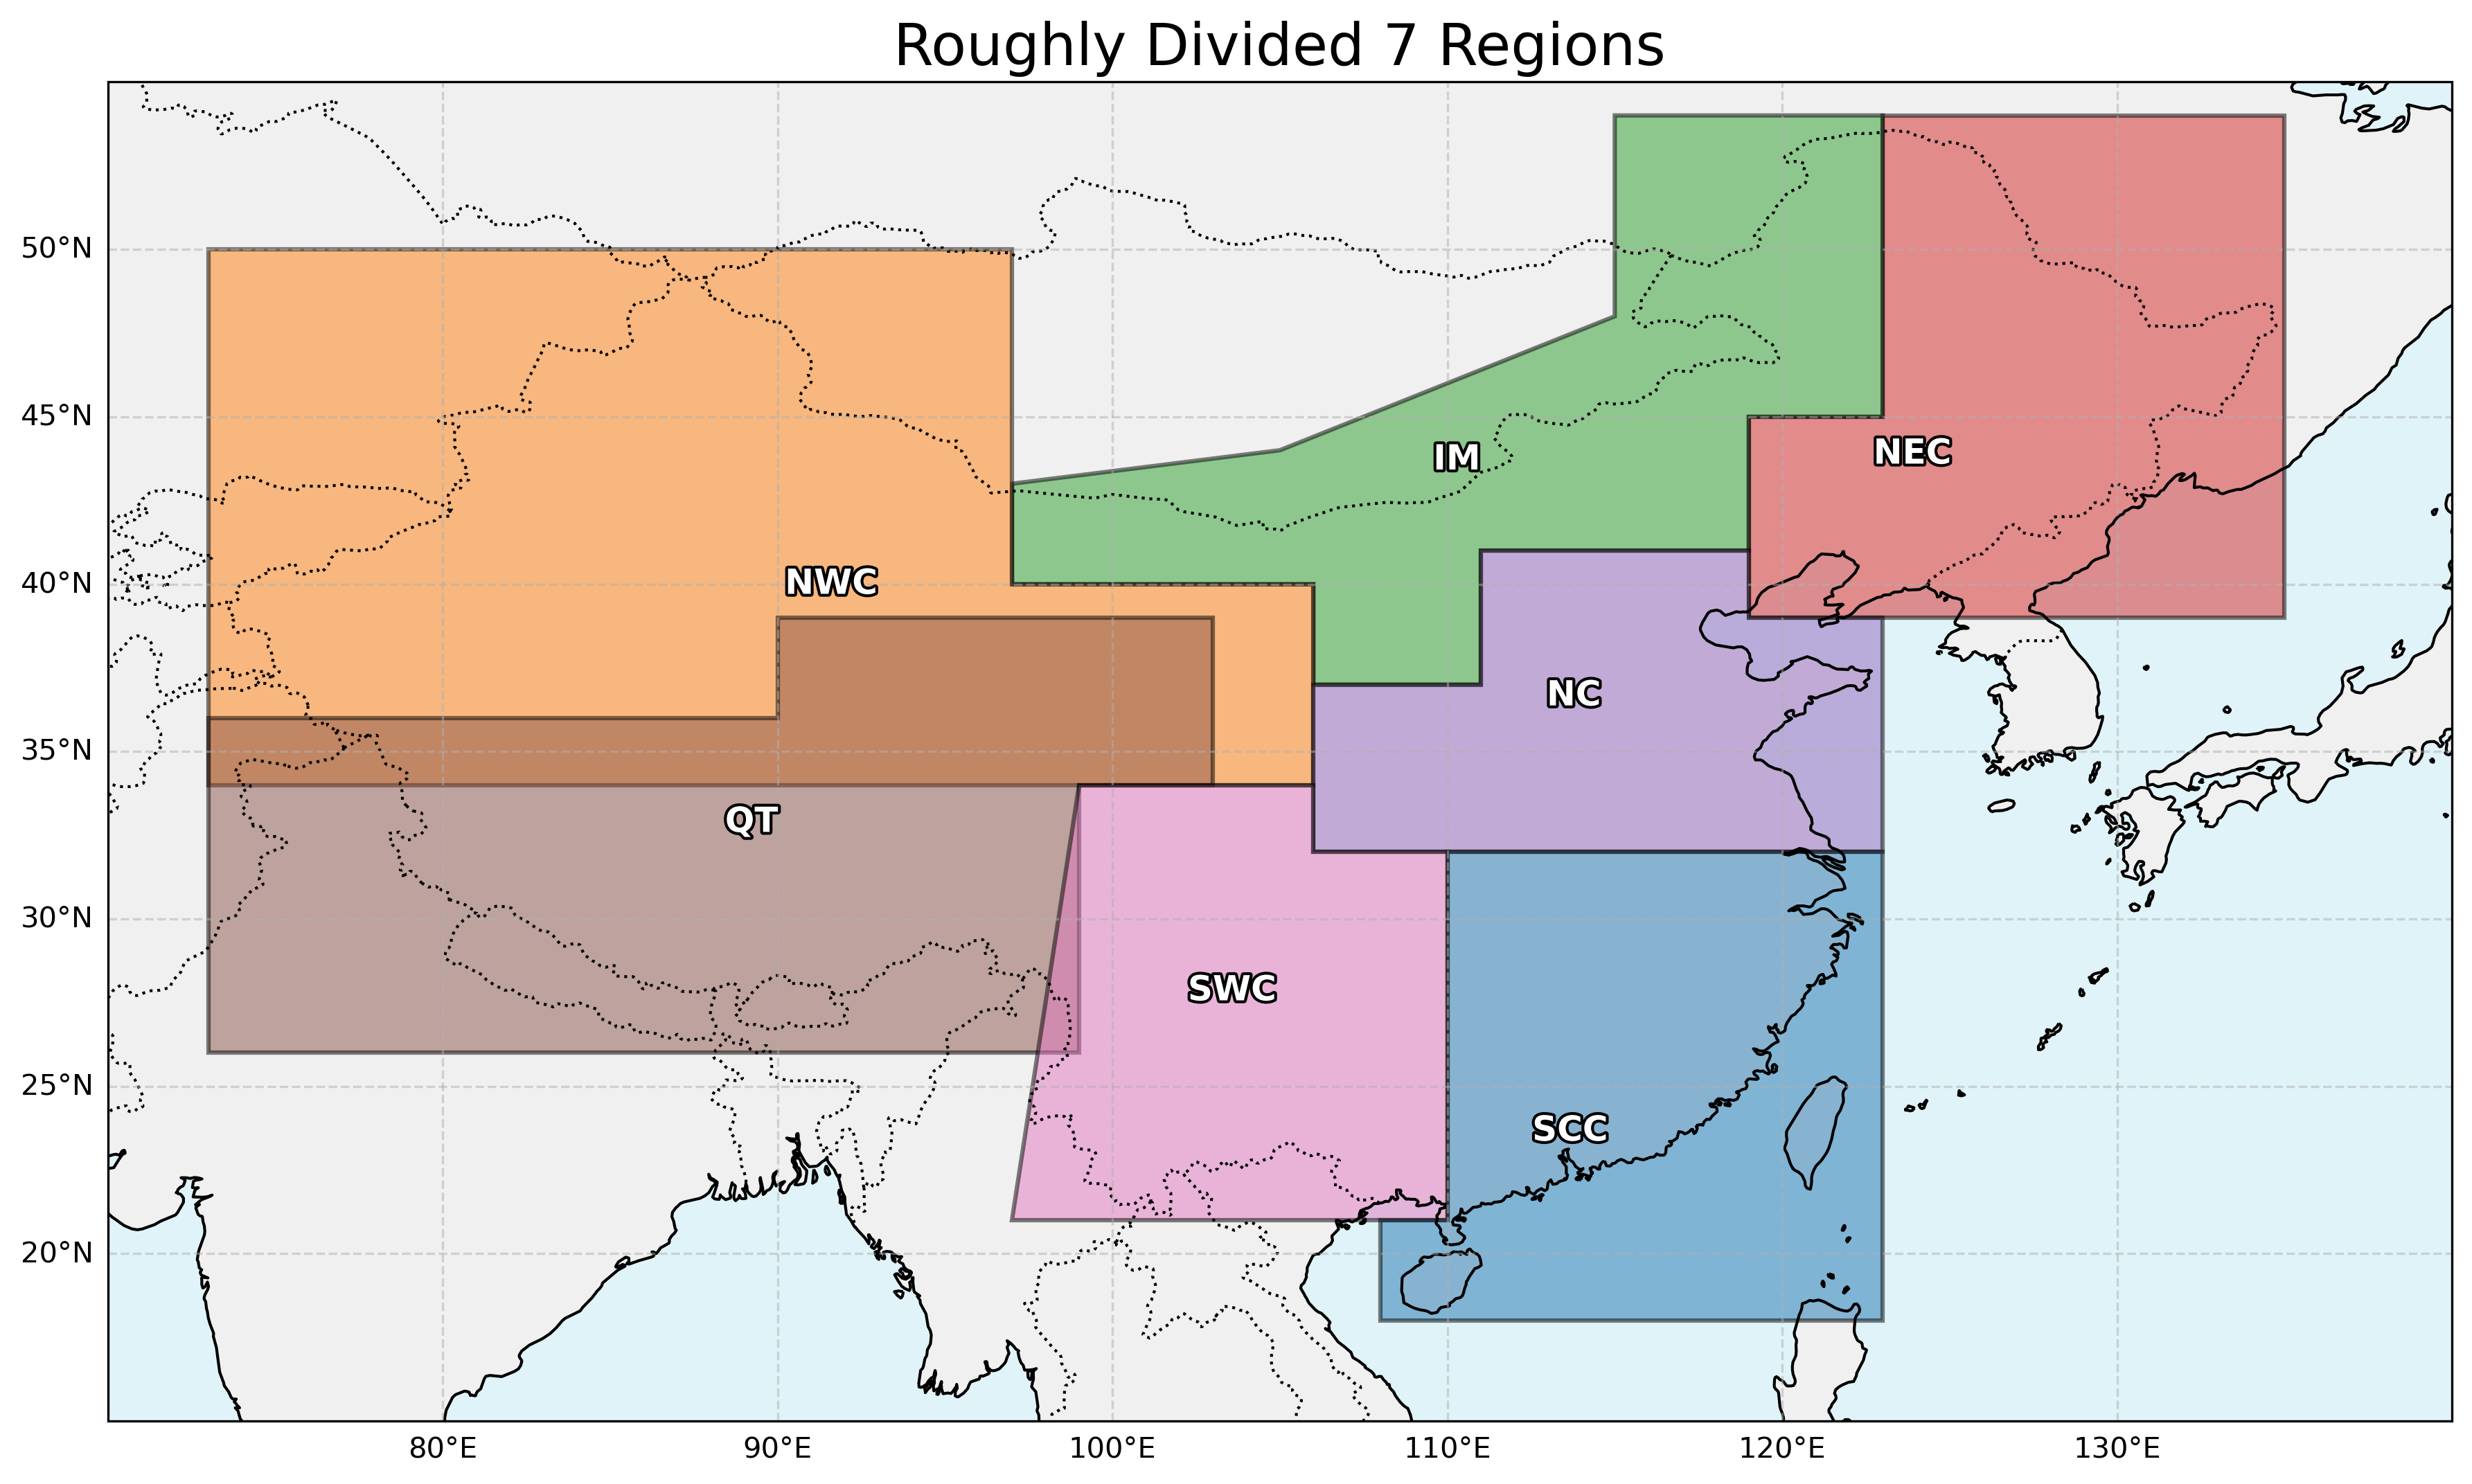

In [31]:
definer = ChinaRegionDefiner()
definer.plot_verification()

In [3]:
import time
import os, sys
import re #导入正则表达式模块，模式匹配、搜索和字符串操作

import numpy as np
import pandas as pd
from numpy import isnan
import random
import math
import xarray as xr
from netCDF4 import Dataset, num2date

import matplotlib
import matplotlib as mpl
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab #3D绘图
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib.cm as cm #色彩控制包
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import FormatStrFormatter
from matplotlib.font_manager import FontProperties
from matplotlib.dates import AutoDateLocator,DayLocator,MonthLocator,HourLocator, DateFormatter, drange

import seaborn as sns
import cmaps #conda install -c conda-forge cmaps
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

from joblib import Parallel, delayed
import itertools
import ipywidgets as widgets
from tqdm import tqdm  #进度条工具库，常用于显示循环的进度条
from subprocess import call
import glob
import pathlib 
from pathlib import Path
from copy import deepcopy

import datetime
from datetime import timedelta
from datetime import date
from datetime import datetime 

import torch
import torch.nn as nn
import torch.nn.functional
import torch.optim as optim
from torch.utils.data import Dataset as TorchDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import TimeSeriesSplit
from sklearn.mixture import GaussianMixture
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from scipy.stats import pearsonr
from scipy.stats import linregress
from scipy.optimize import curve_fit
from scipy import stats

import statsmodels.api as sm#用于统计建模、统计测试和数据探索可视化
from causal_ccm.causal_ccm import ccm #交叉收敛映射算法实现因果推断

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

matplotlib.use('Agg')#一切绘图均只输出在文件夹中
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['SimHei']
########################################################################
#用于将文件名中的“非法”字符替换成下划线 _，然后去掉开始和结尾的空白.
def safe_filename(s: str) -> str:#-> str为类型注解（return type annotation），不会执行。
	s = str(s)
	return "".join(c if (c.isalnum() or c in (' ', '-', '_')) else '_' for c in s).strip()

#提取某个完整文件路径的文件名
def get_filename(filename):
  (filepath,tempfilename) = os.path.split(filename);
  (shotname,extension) = os.path.splitext(tempfilename);
  #return filepath, shotname, extension
  return shotname
########################################################################

In [4]:
vas_tianwen=['Moon_Phase','Moon_Light','Moon_Earth','Sun_Earth','Venus_Earth',
			 'Mercury_Earth','Mars_Earth','Jupiter_Earth','Saturn_Earth',
			 'Lon_Earth','Lon_Moon','Lon_Mercury','Lon_Venus','Lon_Mars',
			 'Lon_Jupiter','Lon_Saturn','Mercury_Mars','Mercury_Venus','Mars_Venus']#金水火三星为近地行星，距离较近，单独算距离。

nc_ERA5_TP = "D://Data_and_Code//ERA5_TP//"  #总降水量的分布
plot_output="D://Data_and_Code//New_Data//Merged_WACCM_MERRA_ISD_SD//Plots_2025-08-31//"

In [5]:
import matplotlib.path as mplPath
# ==========================================
# 第一部分：区域定义类 (复用之前的几何定义)
# ==========================================
class ChinaRegionMasker:
    def __init__(self):
        # 定义区域顶点 (Lon, Lat)
        self.regions = {
            # 1. 东北 (NEC): 黑吉辽
            'NEC': np.array([
                [119, 43], [119, 54], [136, 54], [136, 39], [123, 39], [120, 40], [119, 43]
            ]),
            
            # 2. 内蒙古 (IM): 狭长区域，为了简化，这里定义为一个覆盖主体的多边形
            'IM': np.array([
                [96, 43], [96, 41], [105, 37], [116, 37], [116, 40], 
                [121, 40], [125, 43], [125, 54], [118, 54], [118, 45], 
                [110, 42], [105, 42], [96, 42]
            ]),
            
            # 3. 西北 (NWC): 新疆、甘肃北部
            'NWC': np.array([
                [73, 34], [96, 34], [96, 43], [105, 43], [105, 40], [95, 40], 
                [95, 35], [73, 35], [73, 49], [97, 49], [97, 43], [73, 43]
            ]),
            # 修正 NWC 为更简单的包络框以避免自相交，实际使用建议用 mask 逻辑
            'NWC_Simple': np.array([
                [73, 35], [96, 35], [96, 40], [105, 40], [105, 42], [95, 42], 
                [95, 49], [73, 49]
            ]),

            # 4. 华北 (NC): 京津冀鲁豫晋
            'NC': np.array([
                [105, 32], [123, 32], [123, 40], [116, 40], [116, 37], [105, 37]
            ]),
            
            # 5. 青藏 (QT): 藏青
            'QT': np.array([
                [78, 26], [97, 26], [97, 35], [104, 35], [104, 38], [95, 38], [95, 40], 
                [78, 40]
            ]),
            # 简化版 QT
            'QT_Simple': np.array([
                [78, 27], [98, 27], [98, 35], [104, 35], [104, 40], [78, 40]
            ]),

            # 6. 西南 (SWC): 川渝云贵
            'SWC': np.array([
                [97, 21], [110, 21], [110, 32], [105, 32], [105, 35], 
                [98, 35], [98, 27], [97, 27]
            ]),
            
            # 7. 华南/华中/华东 (SCC): 长江中下游及以南
            'SCC': np.array([
                [108, 18], [123, 18], [123, 32], [110, 32], [110, 21], [108, 21]
            ])
        }

        self.regions = {
            'NEC': self.regions['NEC'],
            'IM': self.regions['IM'],
            'NWC': self.regions['NWC_Simple'],
            'NC': self.regions['NC'],
            'QT': self.regions['QT_Simple'],
            'SWC': self.regions['SWC'],
            'SCC': self.regions['SCC']
        }
        
        #self.paths = {k: Path(v) for k, v in self.regions.items()}
        self.paths = {k: mplPath.Path(v) for k, v in self.regions.items()}

    def get_mask(self, lon_grid, lat_grid):
        """生成与数据网格对应的 Mask"""
        original_shape = lon_grid.shape
        pts = np.column_stack((lon_grid.flatten(), lat_grid.flatten()))
        mask_flat = np.zeros(len(pts), dtype=int)
        
        # 映射关系: 1=NEC, 2=IM, ..., 7=SCC
        region_ids = {name: i+1 for i, name in enumerate(self.regions.keys())}
        
        for name, pid in region_ids.items():
            is_in = self.paths[name].contains_points(pts)
            mask_flat[is_in] = pid
            
        return mask_flat.reshape(original_shape), region_ids

# ==========================================
# 第二部分：批量处理函数 (已修复维度问题)
# ==========================================
def process_nc_folder(folder_path, output_excel):
    nc_files = sorted(glob.glob(os.path.join(folder_path, "*.nc")))
    if not nc_files:
        print(f"错误: 在 {folder_path} 没有找到 .nc 文件")
        return
    print(f"找到 {len(nc_files)} 个文件，准备开始处理...")

    # --- 1. 初始化 Mask ---
    try:
        ds_ref = xr.open_dataset(nc_files[0])
        # 自动识别 lat/lon
        lat_name = 'latitude' if 'latitude' in ds_ref.coords else 'lat'
        lon_name = 'longitude' if 'longitude' in ds_ref.coords else 'lon'
        
        lon_grid, lat_grid = np.meshgrid(ds_ref[lon_name], ds_ref[lat_name])
        
        masker = ChinaRegionMasker()
        mask, region_map_ids = masker.get_mask(lon_grid, lat_grid)
        id_to_name = {v: k for k, v in region_map_ids.items()}
        print("区域掩码 (Mask) 生成完毕。")
        ds_ref.close()
    except Exception as e:
        print(f"初始化 Mask 失败: {e}")
        return

    # --- 2. 循环处理 ---
    results = []
    for f_path in nc_files:
        filename = os.path.basename(f_path)
        try:
            with xr.open_dataset(f_path) as ds:
                # [关键修复] 自动识别时间维度名称
                if 'time' in ds.dims:
                    time_dim = 'time'
                elif 'valid_time' in ds.dims:
                    time_dim = 'valid_time'
                else:
                    raise ValueError(f"未找到时间维度 (time 或 valid_time)，现有维度: {list(ds.dims)}")

                # A. 变量识别 (排除坐标变量)
                var_name = 'tp'
                if var_name not in ds:
                    # 获取除去坐标外的所有变量
                    data_vars = list(ds.data_vars)
                    if data_vars:
                        var_name = data_vars[0]

                # B. 计算日总值 (使用识别到的 time_dim)
                # 注意: sum 操作会压缩掉 time_dim 维度
                daily_sum = ds[var_name].sum(dim=time_dim) * 1000 
                
                # C. 获取时间 (用于表格第一列)
                # 优先从文件名解析，如果失败则读取文件内部时间
                try:
                    parts = filename.split('.')
                    # 假设文件名如 era5.mslp.20200601.nc，取倒数第2段
                    date_part = parts[-2]
                    if len(date_part) == 8 and date_part.isdigit():
                         time_val = f"{date_part[:4]}-{date_part[4:6]}-{date_part[6:]}"
                    else:
                        # 尝试从文件时间变量读取 (取第一个时刻)
                        t_val = ds[time_dim].values[0]
                        time_val = pd.to_datetime(t_val).strftime('%Y-%m-%d')
                except:
                    time_val = filename

                # D. 提取各区域均值
                row_data = {'time': time_val}
                data_np = daily_sum.values # 转为 numpy 数组
                
                for pid, r_name in id_to_name.items():
                    # 提取该区域的所有像素值
                    region_vals = data_np[mask == pid]
                    
                    if len(region_vals) > 0:
                        row_data[r_name] = np.nanmean(region_vals)
                    else:
                        row_data[r_name] = np.nan
                
                results.append(row_data)
                
                if len(results) % 10 == 0:
                    print(f"进度: {len(results)}/{len(nc_files)} | 时间: {time_val}")

        except Exception as e:
            print(f"跳过文件 {filename}: {e}")

    # --- 3. 导出 ---
    if results:
        df = pd.DataFrame(results)
        cols = ['time'] + list(region_map_ids.keys())
        # 补全可能缺失的列
        for col in cols:
            if col not in df.columns: df[col] = np.nan
        df = df[cols]
        
        df.to_excel(output_excel, index=False)
        print(f"\n处理完成! 结果已保存至: {output_excel}")
        print(df.head())
    else:
        print("未生成结果。")

In [6]:
input_folder = nc_ERA5_TP
output_file = "China_Regions_Precipitation.xlsx"

process_nc_folder(input_folder, output_file)

找到 1918 个文件，准备开始处理...
区域掩码 (Mask) 生成完毕。
进度: 10/1918 | 时间: 2020-06-10
进度: 20/1918 | 时间: 2020-06-20
进度: 30/1918 | 时间: 2020-06-30
进度: 40/1918 | 时间: 2020-07-10
进度: 50/1918 | 时间: 2020-07-20
进度: 60/1918 | 时间: 2020-07-30
进度: 70/1918 | 时间: 2020-08-09
进度: 80/1918 | 时间: 2020-08-19
进度: 90/1918 | 时间: 2020-08-29
进度: 100/1918 | 时间: 2020-09-08
进度: 110/1918 | 时间: 2020-09-18
进度: 120/1918 | 时间: 2020-09-28
进度: 130/1918 | 时间: 2020-10-08
进度: 140/1918 | 时间: 2020-10-18
进度: 150/1918 | 时间: 2020-10-28
进度: 160/1918 | 时间: 2020-11-07
进度: 170/1918 | 时间: 2020-11-17
进度: 180/1918 | 时间: 2020-11-27
进度: 190/1918 | 时间: 2020-12-07
进度: 200/1918 | 时间: 2020-12-17
进度: 210/1918 | 时间: 2020-12-27
进度: 220/1918 | 时间: 2021-01-06
进度: 230/1918 | 时间: 2021-01-16
进度: 240/1918 | 时间: 2021-01-26
进度: 250/1918 | 时间: 2021-02-05
进度: 260/1918 | 时间: 2021-02-15
进度: 270/1918 | 时间: 2021-02-25
进度: 280/1918 | 时间: 2021-03-07
进度: 290/1918 | 时间: 2021-03-17
进度: 300/1918 | 时间: 2021-03-27
进度: 310/1918 | 时间: 2021-04-06
进度: 320/1918 | 时间: 2021-04-16
进度: 330/1